# Protein Folding as an Energy Minimisation Problem

The idea here is: a protein folds into the shape that minimises its free energy. If we can write that energy as a function of the configuration, then finding the folded structure is just an optimisation problem, and it can be mapped onto Ising Hamiltonians, which is exactly what quantum annealers and algorithms like VQE are designed to solve.

I'm using the HP (hydrophobic-polar) lattice model, which is a massive simplification of real protein folding but captures the core idea: hydrophobic residues want to be near each other and away from water, and that preference defines an energy landscape.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer import AerSimulator

# the HP model represents a protein as a sequence of two types of amino acids:
# H (hydrophobic) - wants to avoid water, prefers to be buried inside
# P (polar) - happy on the surface in contact with water
#
# a short test sequence - 1 = hydrophobic, 0 = polar
sequence = [1, 0, 1, 1, 0, 1, 0, 1]
N = len(sequence)
print(f"Sequence length: {N}")
print(f"Sequence: {''.join(['H' if s else 'P' for s in sequence])}")

Sequence length: 8
Sequence: HPHHPHPH


## Placing residues on a 2D lattice

Each residue sits on a node of a 2D square lattice. The chain has to be self-avoiding (no two residues on the same site) and connected (each residue is adjacent to the next one in the sequence). I'm encoding moves as directions: 0=up, 1=right, 2=down, 3=left. The first residue is fixed at the origin and the first move is fixed rightward to break symmetry.

In [2]:
MOVES = {
    0: (0, 1),   # up
    1: (1, 0),   # right
    2: (0, -1),  # down
    3: (-1, 0),  # left
}

def decode_fold(sequence, moves):
    """
    Given a sequence of direction choices, lay out the chain on the lattice.
    Returns list of (x,y) positions or None if the fold is invalid (self-intersecting).
    """
    positions = [(0, 0)]
    for m in moves:
        dx, dy = MOVES[m]
        new_pos = (positions[-1][0] + dx, positions[-1][1] + dy)
        if new_pos in positions:
            return None
        positions.append(new_pos)
    return positions

def compute_energy(sequence, positions):
    """
    Energy = negative count of non-bonded H-H contacts.
    Two H residues that are adjacent on the lattice but NOT adjacent in the chain
    contribute -1 to the energy. Lower energy = better fold.
    """
    energy = 0
    pos_set = {pos: i for i, pos in enumerate(positions)}
    for i, pos in enumerate(positions):
        if sequence[i] != 1:
            continue
        for dx, dy in MOVES.values():
            neighbour = (pos[0] + dx, pos[1] + dy)
            if neighbour in pos_set:
                j = pos_set[neighbour]
                if j > i + 1 and sequence[j] == 1:
                    energy -= 1
    return energy

# quick test: a straight line should have zero non-bonded contacts
straight = [1] * (N - 1)
positions = decode_fold(sequence, straight)
print(f"Straight fold energy: {compute_energy(sequence, positions)}")

Straight fold energy: 0


## Brute force: enumerate all valid folds

For short chains we can just try every possible fold. The number of possible move sequences is $4^{N-1}$ but most self-intersect. For N=8 this is manageable, for real proteins (hundreds of residues) it's completely intractable, which is why we need better methods.

In [3]:
valid_folds = []
energies = []

for moves in product(range(4), repeat=N-2):
    full_moves = [1] + list(moves)
    positions = decode_fold(sequence, full_moves)
    if positions is not None:
        e = compute_energy(sequence, positions)
        valid_folds.append(positions)
        energies.append(e)

energies = np.array(energies)
print(f"Total valid folds: {len(valid_folds)}")
print(f"Energy range: [{energies.min()}, {energies.max()}]")
print(f"Number of ground state folds: {np.sum(energies == energies.min())}")
print(f"Ground state energy: {energies.min()}")

Total valid folds: 543
Energy range: [-3, 0]
Number of ground state folds: 8
Ground state energy: -3


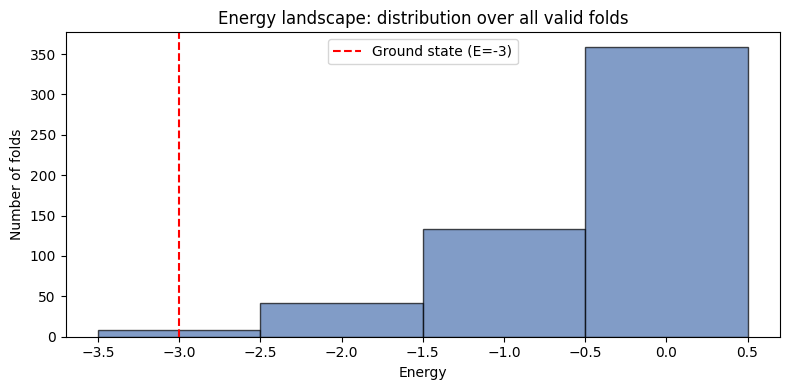

In [4]:
# distribution of energies across all valid folds
# this is the energy landscape - most folds are mediocre, very few are optimal

plt.figure(figsize=(8, 4))
plt.hist(energies, bins=range(int(energies.min()), int(energies.max()) + 2),
         edgecolor='black', alpha=0.7, align='left', color='#4C72B0')
plt.xlabel('Energy')
plt.ylabel('Number of folds')
plt.title('Energy landscape: distribution over all valid folds')
plt.axvline(x=energies.min(), color='red', linestyle='--', label=f'Ground state (E={energies.min():.0f})')
plt.legend()
plt.tight_layout()
plt.show()

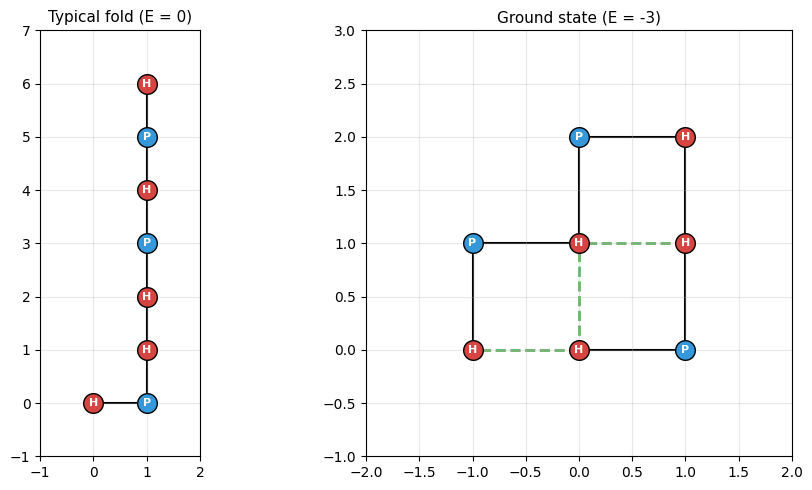

In [5]:
def plot_fold(sequence, positions, energy, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]
    ax.plot(xs, ys, 'k-', linewidth=1.5, zorder=1)

    for i, (x, y) in enumerate(positions):
        color = '#D64541' if sequence[i] == 1 else '#3498DB'
        label = 'H' if sequence[i] == 1 else 'P'
        ax.scatter(x, y, c=color, s=200, zorder=2, edgecolors='black', linewidth=1)
        ax.annotate(label, (x, y), ha='center', va='center', fontsize=8,
                    fontweight='bold', color='white')

    # highlight non-bonded H-H contacts
    pos_set = {pos: i for i, pos in enumerate(positions)}
    for i, pos in enumerate(positions):
        if sequence[i] != 1:
            continue
        for dx, dy in MOVES.values():
            nb = (pos[0] + dx, pos[1] + dy)
            if nb in pos_set:
                j = pos_set[nb]
                if j > i + 1 and sequence[j] == 1:
                    ax.plot([pos[0], nb[0]], [pos[1], nb[1]], 'g--',
                            linewidth=2, alpha=0.6, zorder=0)

    ax.set_title(f'Energy = {energy}', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(min(xs)-1, max(xs)+1)
    ax.set_ylim(min(ys)-1, max(ys)+1)

ground_idx = np.where(energies == energies.min())[0][0]
mid_idx = np.where(energies == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_fold(sequence, valid_folds[mid_idx], 0, axes[0])
axes[0].set_title('Typical fold (E = 0)', fontsize=11)
plot_fold(sequence, valid_folds[ground_idx], energies.min(), axes[1])
axes[1].set_title(f'Ground state (E = {energies.min():.0f})', fontsize=11)
plt.tight_layout()
plt.show()

## Encoding folding decisions as qubits

The brute force above solves the problem classically. Now I want the quantum computer to do it.

The idea: each qubit represents a folding decision, and the Hamiltonian encodes rules as Pauli operators. The quantum system evaluates the energy itself from operator algebra. No precomputed energy table is passed in.

For a 4-residue all-H chain (HHHH) with the first move fixed rightward, there are 2 free moves. Each needs 2 qubits to encode 4 directions, so 4 qubits total.

The physical rules:
1. **Contact reward**: if residue 3 ends up lattice-adjacent to residue 0, that is a non-bonded H-H contact worth $-1$
2. **Collision penalty**: if any residue lands on an occupied site, the fold is invalid

Both conditions translate into projectors built from $Z$ operators. The projector $|0\rangle\langle 0| = (I+Z)/2$ picks out qubit state 0; $|1\rangle\langle 1| = (I-Z)/2$ picks out state 1. Products of these select specific multi-qubit configurations.

In [6]:
# 4-residue chain HHHH, first move fixed rightward
# 2 free moves x 2 qubits each = 4 qubits
#
# qubit encoding:
#   move 1 direction = 2*q1 + q0   (00=up, 01=right, 10=down, 11=left)
#   move 2 direction = 2*q3 + q2

seq_small = [1, 1, 1, 1]  # HHHH
N_small = len(seq_small)
n_qubits_vqe = 4

# positions after fixed first move: R0=(0,0), R1=(1,0)
# R2 depends on move1, R3 depends on move1+move2

# helper: Z on a specific qubit in Qiskit's SparsePauliOp convention
def Z_op(qubit):
    label = ['I'] * n_qubits_vqe
    label[n_qubits_vqe - 1 - qubit] = 'Z'
    return SparsePauliOp(''.join(label))

I4 = SparsePauliOp('IIII')

# CONTACT REWARD
# R3 is adjacent to R0=(0,0) exactly when:
#   move2 = left  (q2=1, q3=1)  AND  move1 has q0=0 (up or down both work)
#
# working through the geometry:
#   move1=up   → R2=(1,1), move2=left → R3=(0,1), adjacent to R0 ✓
#   move1=down → R2=(1,-1), move2=left → R3=(0,-1), adjacent to R0 ✓
#   move1=right with move2=left → R3 lands back on R1 (collision, handled below)
#   move1=left → R2 collides with R0 (collision, handled below)

P_contact = ((I4 + Z_op(0)) @ (I4 - Z_op(2)) @ (I4 - Z_op(3)) / 8).simplify()
H_contact = (-1.0 * P_contact).simplify()

# COLLISION PENALTIES
# Type A: move1=left (q0=1, q1=1) puts R2 on R0
P_coll_A = ((I4 - Z_op(0)) @ (I4 - Z_op(1)) / 4).simplify()

# Type B: move2 reverses move1, putting R3 back on R1
#   up then down:    q0=0,q1=0 then q2=0,q3=1
P_rev1 = ((I4+Z_op(0)) @ (I4+Z_op(1)) @ (I4+Z_op(2)) @ (I4-Z_op(3)) / 16).simplify()
#   down then up:    q0=0,q1=1 then q2=0,q3=0
P_rev2 = ((I4+Z_op(0)) @ (I4-Z_op(1)) @ (I4+Z_op(2)) @ (I4+Z_op(3)) / 16).simplify()
#   right then left: q0=1,q1=0 then q2=1,q3=1
P_rev3 = ((I4-Z_op(0)) @ (I4+Z_op(1)) @ (I4-Z_op(2)) @ (I4-Z_op(3)) / 16).simplify()

P_coll_B = (P_rev1 + P_rev2 + P_rev3).simplify()

penalty = 10
H_protein = (H_contact + penalty * (P_coll_A + P_coll_B)).simplify()

print(f"Hamiltonian: {len(H_protein)} Pauli terms on {H_protein.num_qubits} qubits")
print(f"\nPauli terms:")
for pauli, coeff in zip(H_protein.paulis, H_protein.coeffs):
    if abs(coeff) > 1e-10:
        print(f"  {pauli}: {np.real(coeff):+.4f}")

Hamiltonian: 16 Pauli terms on 4 qubits

Pauli terms:
  IIII: +4.2500
  ZIII: -0.5000
  IZII: +0.7500
  ZZII: +0.5000
  IIIZ: -2.0000
  ZIIZ: +0.7500
  IZIZ: +2.0000
  ZZIZ: -0.7500
  IIZI: -1.8750
  IIZZ: +1.8750
  ZIZI: -1.8750
  IZZI: -0.6250
  ZZZI: -0.6250
  ZIZZ: -0.6250
  IZZZ: +0.6250
  ZZZZ: -1.8750


In [ ]:
# verify the Pauli Hamiltonian against brute force for every basis state
H_matrix = H_protein.to_matrix()
energies_pauli = np.real(np.diag(H_matrix))

dir_names = {0: 'up', 1: 'right', 2: 'down', 3: 'left'}

print("Pauli Hamiltonian vs brute force (all 16 states):\n")
all_match = True
for i in range(16):
    q0, q1, q2, q3 = (i>>0)&1, (i>>1)&1, (i>>2)&1, (i>>3)&1
    m1 = 2*q1 + q0
    m2 = 2*q3 + q2
    pos = decode_fold(seq_small, [1, m1, m2])
    
    if pos is None:
        ok = energies_pauli[i] > 0
        if not ok: all_match = False
        print(f"  |{i:04b}>  {dir_names[m1]:>5s},{dir_names[m2]:<5s}  "
              f"COLLISION         E_pauli={energies_pauli[i]:+5.1f}")
    else:
        bf_e = compute_energy(seq_small, pos)
        ok = abs(energies_pauli[i] - bf_e) < 0.01
        if not ok: all_match = False
        tag = 'GROUND STATE' if bf_e < 0 else ''
        print(f"  |{i:04b}>  {dir_names[m1]:>5s},{dir_names[m2]:<5s}  "
              f"R3={str(pos[3]):>8s}  E_pauli={energies_pauli[i]:+5.1f}  "
              f"E_brute={bf_e:+.1f}{tag}")

print(f"\nAll energies match: {all_match}")

Pauli Hamiltonian vs brute force (all 16 states):

  |0000>     up,up     R3=  (1, 2)  E_pauli= +0.0  E_brute=+0.0  ✓
  |0001>  right,up     R3=  (2, 1)  E_pauli= +0.0  E_brute=+0.0  ✓
  |0010>   down,up     COLLISION         E_pauli=+10.0  ✓
  |0011>   left,up     COLLISION         E_pauli=+10.0  ✓
  |0100>     up,right  R3=  (2, 1)  E_pauli= +0.0  E_brute=+0.0  ✓
  |0101>  right,right  R3=  (3, 0)  E_pauli= +0.0  E_brute=+0.0  ✓
  |0110>   down,right  R3= (2, -1)  E_pauli= +0.0  E_brute=+0.0  ✓
  |0111>   left,right  COLLISION         E_pauli=+10.0  ✓
  |1000>     up,down   COLLISION         E_pauli=+10.0  ✓
  |1001>  right,down   R3= (2, -1)  E_pauli= +0.0  E_brute=+0.0  ✓
  |1010>   down,down   R3= (1, -2)  E_pauli= +0.0  E_brute=+0.0  ✓
  |1011>   left,down   COLLISION         E_pauli=+10.0  ✓
  |1100>     up,left   R3=  (0, 1)  E_pauli= -1.0  E_brute=-1.0  ✓ ← GROUND STATE
  |1101>  right,left   COLLISION         E_pauli=+10.0  ✓
  |1110>   down,left   R3= (0, -1)  E_pauli= -1.0 

## Solving with VQE (simulator)

VQE searches over parameterised quantum states to minimise $\langle\psi(\theta)|H|\psi(\theta)\rangle$. The Hamiltonian encodes the physics as Pauli operators, and the circuit explores configuration space. No energy table was passed in; the energy emerges from operator structure.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_33952\3117951577.py:4: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(n_qubits_vqe, reps=2, entanglement='linear')


Ansatz: 24 parameters


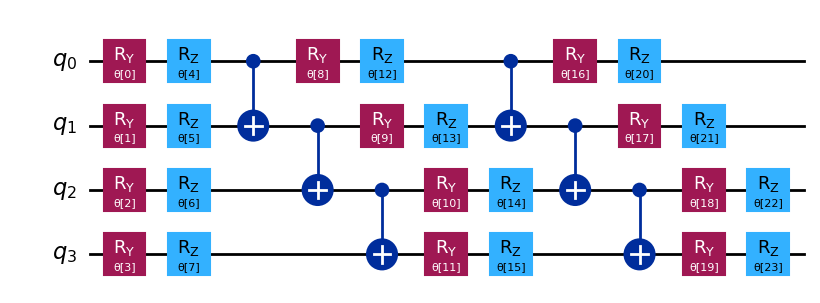

In [8]:
from qiskit.circuit.library import EfficientSU2
from scipy.optimize import minimize

ansatz = EfficientSU2(n_qubits_vqe, reps=2, entanglement='linear')
print(f"Ansatz: {ansatz.num_parameters} parameters")
ansatz.decompose().draw('mpl', fold=50)

In [9]:
def vqe_cost(params, ansatz, hamiltonian):
    qc = ansatz.assign_parameters(params)
    sv = Statevector.from_instruction(qc)
    return np.real(sv.expectation_value(hamiltonian))

best_energy = np.inf
best_params = None
vqe_history = []

for trial in range(15):
    x0 = np.random.randn(ansatz.num_parameters) * np.pi
    trial_hist = []
    def callback(p):
        trial_hist.append(vqe_cost(p, ansatz, H_protein))
    res = minimize(vqe_cost, x0, args=(ansatz, H_protein),
                   method='COBYLA', callback=callback,
                   options={'maxiter': 300})
    vqe_history.extend(trial_hist)
    if res.fun < best_energy:
        best_energy = res.fun
        best_params = res.x
        print(f"  Trial {trial}: new best = {best_energy:.4f}")

true_ground = min(energies_pauli[i] for i in range(16)
                  if decode_fold(seq_small, [1, 2*((i>>1)&1)+((i>>0)&1),
                                             2*((i>>3)&1)+((i>>2)&1)]) is not None)
print(f"\nVQE result: {best_energy:.4f}")
print(f"True ground state: {true_ground:.1f}")
print(f"Match: {abs(best_energy - true_ground) < 0.1}")

  Trial 0: new best = 0.0036
  Trial 1: new best = -0.9958

VQE result: -0.9958
True ground state: -1.0
Match: True


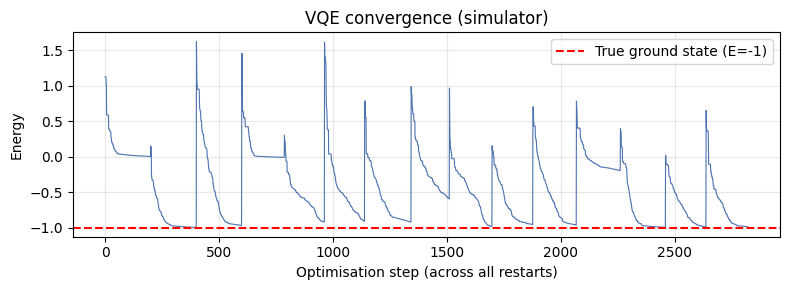

In [10]:
plt.figure(figsize=(8, 3))
plt.plot(vqe_history, color='#4C72B0', linewidth=0.8)
plt.axhline(y=true_ground, color='red', linestyle='--',
            label=f'True ground state (E={true_ground:.0f})')
plt.xlabel('Optimisation step (across all restarts)')
plt.ylabel('Energy')
plt.title('VQE convergence (simulator)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# simulator measurement distribution
qc_sim = ansatz.assign_parameters(best_params)
sv_sim = Statevector.from_instruction(qc_sim)
probs_sim = sv_sim.probabilities()

print("Top 5 states (simulator):")
for idx in np.argsort(probs_sim)[::-1][:5]:
    m1 = 2*((idx>>1)&1) + ((idx>>0)&1)
    m2 = 2*((idx>>3)&1) + ((idx>>2)&1)
    pos = decode_fold(seq_small, [1, m1, m2])
    e = energies_pauli[idx]
    tag = '← GROUND STATE' if pos is not None and e < -0.5 else ('(collision)' if pos is None else '')
    print(f"  |{idx:04b}> prob={probs_sim[idx]:.4f}  {dir_names[m1]:>5s},{dir_names[m2]:<5s}  E={e:+.1f}  {tag}")

Top 5 states (simulator):
  |1110> prob=0.9862   down,left   E=-1.0  ← GROUND STATE
  |1100> prob=0.0100     up,left   E=-1.0  ← GROUND STATE
  |0100> prob=0.0034     up,right  E=+0.0  
  |0110> prob=0.0002   down,right  E=+0.0  
  |0000> prob=0.0001     up,up     E=+0.0  


## Running on IBM quantum hardware

Same circuit, same optimised parameters, but now on a real quantum processor. The circuit was optimised on the simulator; here I just run the final state preparation on hardware and compare the measurement statistics. Noise from real qubits will smear the distribution, but if the ground state signal survives, that is a meaningful result.

**Setup** (run once before this section):
```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="", overwrite=True)
```
This saves your token locally so it never appears in the notebook.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit import transpile as transpile_circuit

service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance=''
)
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
print(f"Backend: {backend.name}")
print(f"Qubits: {backend.num_qubits}")

Backend: ibm_marrakesh
Qubits: 156


Transpiled depth: 25
Gate counts: {'rz': 32, 'sx': 28, 'cz': 6, 'measure': 4, 'barrier': 1}


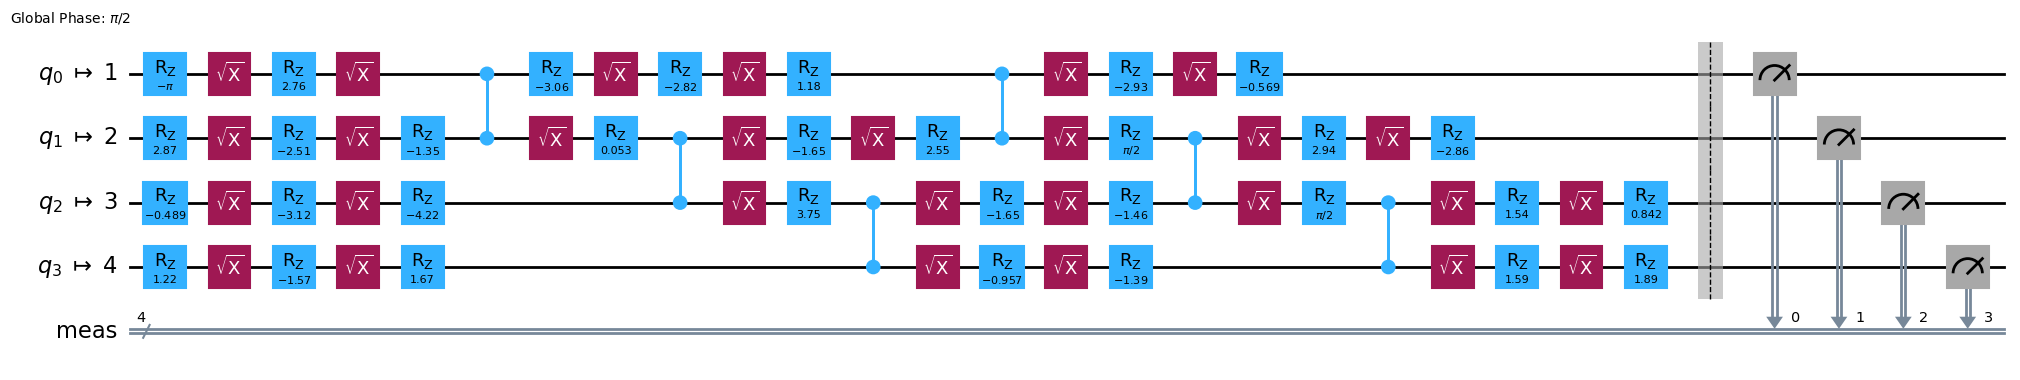

In [15]:
# build the measured circuit with optimised parameters from simulator VQE
qc_hw = ansatz.assign_parameters(best_params)
qc_hw.measure_all()

# transpile for the hardware topology
qc_transpiled = transpile_circuit(qc_hw, backend=backend, optimization_level=3)
print(f"Transpiled depth: {qc_transpiled.depth()}")
print(f"Gate counts: {dict(qc_transpiled.count_ops())}")

qc_transpiled.draw('mpl', fold=60)

In [17]:
# run on hardware
import time

n_shots = 4096
sampler = SamplerV2(backend)

t_start = time.time()
job = sampler.run([qc_transpiled], shots=n_shots)
print(f"Job ID: {job.job_id()}")
print("Waiting for results...")

result = job.result()
t_end = time.time()

counts_hw = result[0].data.meas.get_counts()

# timing breakdown
job_metrics = job.metrics()
print(f"\n--- Execution stats ---")
print(f"Total wall time: {t_end - t_start:.1f}s")
if 'usage' in job_metrics:
    usage = job_metrics['usage']
    if 'quantum_seconds' in usage:
        print(f"QPU time: {usage['quantum_seconds']:.3f}s")
    elif 'seconds' in usage:
        print(f"QPU time: {usage['seconds']:.3f}s")
print(f"Shots: {n_shots}")
print(f"Circuit depth (transpiled): {qc_transpiled.depth()}")
print(f"Backend: {backend.name}")

print(f"\nTop 5 measured states (hardware):")
sorted_counts = sorted(counts_hw.items(), key=lambda x: x[1], reverse=True)
for bitstr, count in sorted_counts[:5]:
    idx = int(bitstr, 2)
    m1 = 2*((idx>>1)&1) + ((idx>>0)&1)
    m2 = 2*((idx>>3)&1) + ((idx>>2)&1)
    pos = decode_fold(seq_small, [1, m1, m2])
    e = energies_pauli[idx]
    tag = 'GROUND STATE' if pos is not None and e < -0.5 else ('(collision)' if pos is None else '')
    print(f"  |{bitstr}> count={count:4d} ({count/n_shots:.3f})  "
          f"{dir_names[m1]:>5s},{dir_names[m2]:<5s}  E={e:+.1f}  {tag}")

Job ID: d6hf9tathhns739232q0
Waiting for results...

--- Execution stats ---
Total wall time: 9.6s
QPU time: 3.000s
Shots: 4096
Circuit depth (transpiled): 25
Backend: ibm_marrakesh

Top 5 measured states (hardware):
  |1110> count=3738 (0.913)   down,left   E=-1.0  GROUND STATE
  |0110> count= 108 (0.026)   down,right  E=+0.0  
  |1010> count=  64 (0.016)   down,down   E=+0.0  
  |1100> count=  57 (0.014)     up,left   E=-1.0  GROUND STATE
  |0100> count=  42 (0.010)     up,right  E=+0.0  


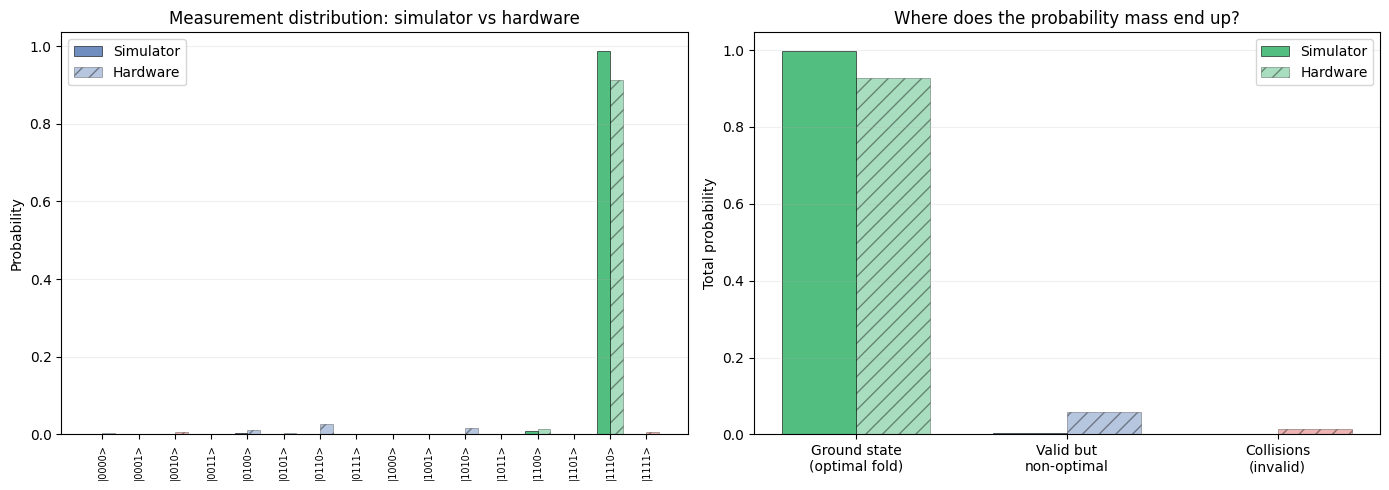


Ground state probability:  simulator=0.996  hardware=0.927
Collision probability:     simulator=0.000  hardware=0.015


In [18]:
# simulator vs hardware comparison
probs_hw = np.zeros(16)
for bitstr, count in counts_hw.items():
    idx = int(bitstr, 2)
    probs_hw[idx] = count / n_shots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart comparison
labels = [f'|{i:04b}>' for i in range(16)]
x = np.arange(16)
width = 0.35

# colour by type: green=ground state, blue=valid, red=collision
colours_sim = []
colours_hw = []
for i in range(16):
    m1 = 2*((i>>1)&1) + ((i>>0)&1)
    m2 = 2*((i>>3)&1) + ((i>>2)&1)
    pos = decode_fold(seq_small, [1, m1, m2])
    if pos is None:
        colours_sim.append('#D64541')
        colours_hw.append('#D64541')
    elif energies_pauli[i] < -0.5:
        colours_sim.append('#27AE60')
        colours_hw.append('#27AE60')
    else:
        colours_sim.append('#4C72B0')
        colours_hw.append('#4C72B0')

axes[0].bar(x - width/2, probs_sim, width, color=colours_sim, alpha=0.8,
            edgecolor='black', linewidth=0.5, label='Simulator')
axes[0].bar(x + width/2, probs_hw, width, color=colours_hw, alpha=0.4,
            edgecolor='black', linewidth=0.5, label='Hardware', hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=90, fontsize=7)
axes[0].set_ylabel('Probability')
axes[0].set_title('Measurement distribution: simulator vs hardware')
axes[0].legend()
axes[0].grid(True, alpha=0.2, axis='y')

# ground state probability comparison
gs_indices = [i for i in range(16) if energies_pauli[i] < -0.5
              and decode_fold(seq_small, [1, 2*((i>>1)&1)+((i>>0)&1),
                                          2*((i>>3)&1)+((i>>2)&1)]) is not None]
gs_prob_sim = sum(probs_sim[i] for i in gs_indices)
gs_prob_hw = sum(probs_hw[i] for i in gs_indices)

collision_indices = [i for i in range(16) if decode_fold(
    seq_small, [1, 2*((i>>1)&1)+((i>>0)&1), 2*((i>>3)&1)+((i>>2)&1)]) is None]
coll_prob_sim = sum(probs_sim[i] for i in collision_indices)
coll_prob_hw = sum(probs_hw[i] for i in collision_indices)

other_prob_sim = 1 - gs_prob_sim - coll_prob_sim
other_prob_hw = 1 - gs_prob_hw - coll_prob_hw

categories = ['Ground state\n(optimal fold)', 'Valid but\nnon-optimal', 'Collisions\n(invalid)']
sim_vals = [gs_prob_sim, other_prob_sim, coll_prob_sim]
hw_vals = [gs_prob_hw, other_prob_hw, coll_prob_hw]

x2 = np.arange(3)
axes[1].bar(x2 - width/2, sim_vals, width, color=['#27AE60', '#4C72B0', '#D64541'],
            alpha=0.8, edgecolor='black', linewidth=0.5, label='Simulator')
axes[1].bar(x2 + width/2, hw_vals, width, color=['#27AE60', '#4C72B0', '#D64541'],
            alpha=0.4, edgecolor='black', linewidth=0.5, label='Hardware', hatch='//')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Total probability')
axes[1].set_title('Where does the probability mass end up?')
axes[1].legend()
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

print(f"\nGround state probability:  simulator={gs_prob_sim:.3f}  hardware={gs_prob_hw:.3f}")
print(f"Collision probability:     simulator={coll_prob_sim:.3f}  hardware={coll_prob_hw:.3f}")

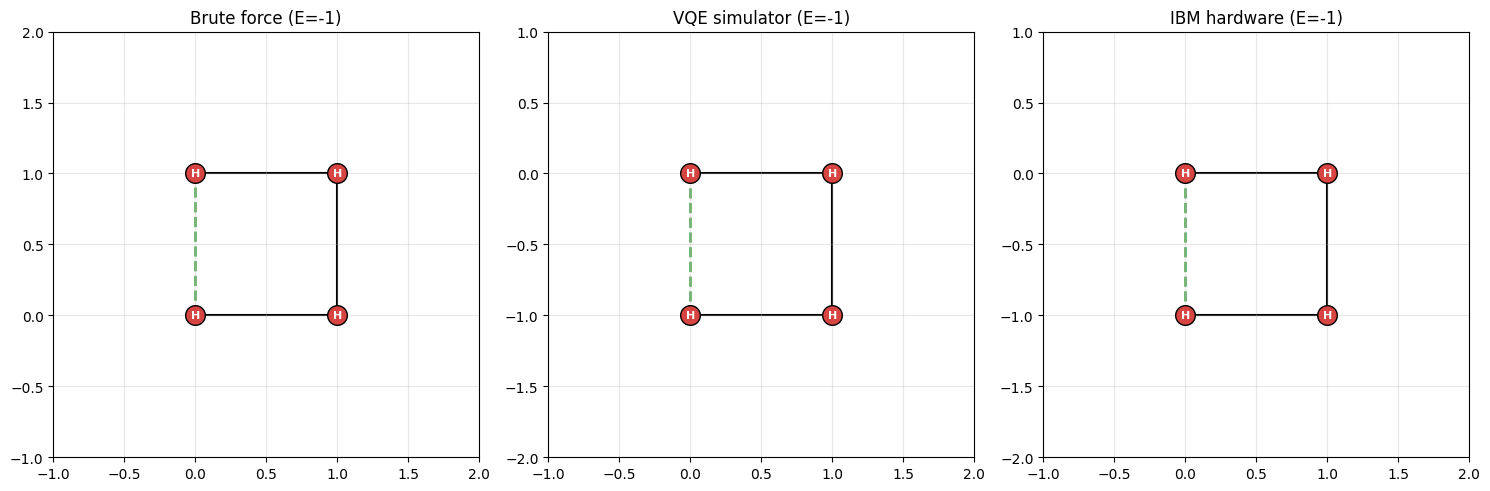

In [19]:
# decode the most probable hardware state and compare folds
best_hw_bitstr = max(counts_hw, key=counts_hw.get)
best_hw_idx = int(best_hw_bitstr, 2)
m1_hw = 2*((best_hw_idx>>1)&1) + ((best_hw_idx>>0)&1)
m2_hw = 2*((best_hw_idx>>3)&1) + ((best_hw_idx>>2)&1)
pos_hw = decode_fold(seq_small, [1, m1_hw, m2_hw])

# simulator best
best_sim_idx = np.argmax(probs_sim)
m1_sim = 2*((best_sim_idx>>1)&1) + ((best_sim_idx>>0)&1)
m2_sim = 2*((best_sim_idx>>3)&1) + ((best_sim_idx>>2)&1)
pos_sim = decode_fold(seq_small, [1, m1_sim, m2_sim])

# brute force best
bf_best_e = 0
bf_best_pos = None
for moves in product(range(4), repeat=N_small-2):
    full = [1] + list(moves)
    pos = decode_fold(seq_small, full)
    if pos is not None:
        e = compute_energy(seq_small, pos)
        if e < bf_best_e:
            bf_best_e = e
            bf_best_pos = pos

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_fold(seq_small, bf_best_pos, bf_best_e, axes[0])
axes[0].set_title(f'Brute force (E={bf_best_e:.0f})')

if pos_sim is not None:
    e_sim = compute_energy(seq_small, pos_sim)
    plot_fold(seq_small, pos_sim, e_sim, axes[1])
    axes[1].set_title(f'VQE simulator (E={e_sim:.0f})')
else:
    axes[1].text(0.5, 0.5, 'Invalid fold', ha='center', va='center', fontsize=12)
    axes[1].set_title('VQE simulator (invalid)')

if pos_hw is not None:
    e_hw = compute_energy(seq_small, pos_hw)
    plot_fold(seq_small, pos_hw, e_hw, axes[2])
    axes[2].set_title(f'IBM hardware (E={e_hw:.0f})')
else:
    axes[2].text(0.5, 0.5, 'Invalid fold', ha='center', va='center', fontsize=12)
    axes[2].set_title('IBM hardware (invalid)')

plt.tight_layout()
plt.show()

## Noise analysis

Real quantum hardware introduces errors from gate errors and decoherence. 
How much does this degrade the result? I can quantify this by looking at how the probability distribution 
shifts away from the ideal simulator output.

In [20]:
# quantify the noise impact
from scipy.stats import entropy

# KL divergence: how far is hardware from ideal?
# add small epsilon to avoid log(0)
eps = 1e-10
probs_sim_safe = np.clip(probs_sim, eps, 1)
probs_hw_safe = np.clip(probs_hw, eps, 1)
kl_div = entropy(probs_hw_safe, probs_sim_safe)

# total variation distance: worst-case distinguishability
tvd = 0.5 * np.sum(np.abs(probs_sim - probs_hw))

# hellinger distance
hellinger = np.sqrt(1 - np.sum(np.sqrt(probs_sim_safe * probs_hw_safe)))

# effective error rate: fraction of shots that landed on wrong answer
gs_indices = [i for i in range(16) if energies_pauli[i] < -0.5
              and decode_fold(seq_small, [1, 2*((i>>1)&1)+((i>>0)&1),
                                          2*((i>>3)&1)+((i>>2)&1)]) is not None]
gs_prob_sim = sum(probs_sim[i] for i in gs_indices)
gs_prob_hw = sum(probs_hw[i] for i in gs_indices)

print("--- Noise metrics ---")
print(f"KL divergence (hw || sim):    {kl_div:.4f}")
print(f"Total variation distance:     {tvd:.4f}")
print(f"Hellinger distance:           {hellinger:.4f}")
print(f"")
print(f"Ground state probability:")
print(f"  Simulator: {gs_prob_sim:.3f}")
print(f"  Hardware:  {gs_prob_hw:.3f}")
print(f"  Degradation: {gs_prob_sim - gs_prob_hw:+.3f}")
print(f"")

# per-state error
print("Per-state probability shift (|sim - hw|):")
shifts = []
for i in range(16):
    diff = abs(probs_sim[i] - probs_hw[i])
    shifts.append(diff)
    if diff > 0.02:
        m1 = 2*((i>>1)&1) + ((i>>0)&1)
        m2 = 2*((i>>3)&1) + ((i>>2)&1)
        print(f"  |{i:04b}> sim={probs_sim[i]:.3f} hw={probs_hw[i]:.3f} shift={diff:+.3f}")

--- Noise metrics ---
KL divergence (hw || sim):    0.2850
Total variation distance:     0.0736
Hellinger distance:           0.1698

Ground state probability:
  Simulator: 0.996
  Hardware:  0.927
  Degradation: +0.070

Per-state probability shift (|sim - hw|):
  |0110> sim=0.000 hw=0.026 shift=+0.026
  |1110> sim=0.986 hw=0.913 shift=+0.074


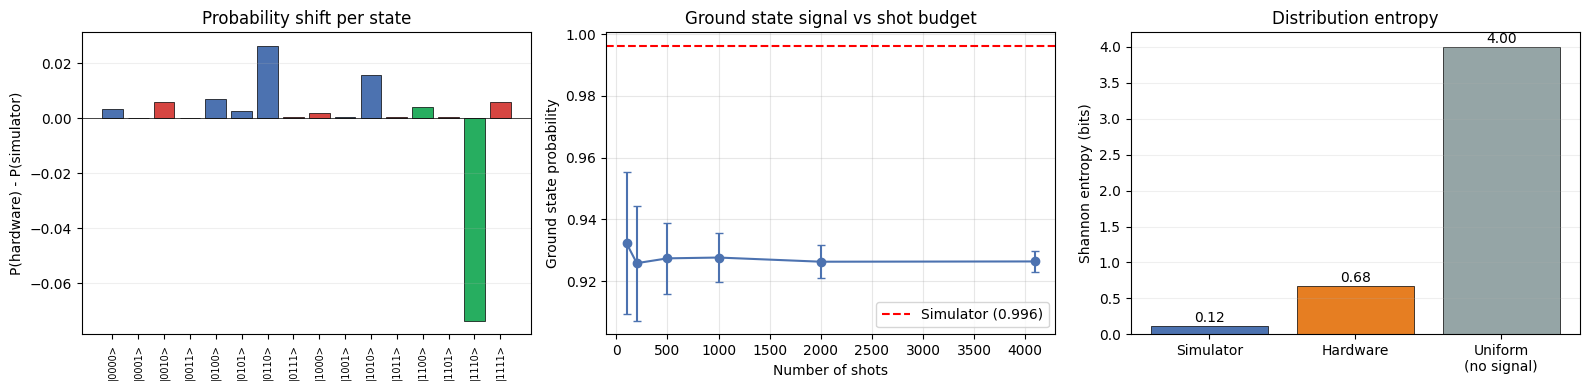


Entropy: simulator=0.12 bits, hardware=0.68 bits, uniform=4.00 bits
Hardware entropy is 17% of maximum (uniform). Lower = more signal preserved.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. per-state probability shift
shifts = probs_hw - probs_sim
colours_shift = ['#27AE60' if i in gs_indices else '#D64541' if
                 decode_fold(seq_small, [1, 2*((i>>1)&1)+((i>>0)&1),
                             2*((i>>3)&1)+((i>>2)&1)]) is None
                 else '#4C72B0' for i in range(16)]
axes[0].bar(range(16), shifts, color=colours_shift, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(16))
axes[0].set_xticklabels([f'|{i:04b}>' for i in range(16)], rotation=90, fontsize=7)
axes[0].set_ylabel('P(hardware) - P(simulator)')
axes[0].set_title('Probability shift per state')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.2, axis='y')

# 2. cumulative probability on ground states vs shots
# simulate what happens as we increase shot count
np.random.seed(42)
shot_counts_test = [100, 200, 500, 1000, 2000, 4096]
gs_frac_vs_shots = []

# from hardware counts, resample
all_hw_shots = []
for bitstr, count in counts_hw.items():
    all_hw_shots.extend([int(bitstr, 2)] * count)
all_hw_shots = np.array(all_hw_shots)

for ns in shot_counts_test:
    trials = []
    for _ in range(50):
        sample = np.random.choice(all_hw_shots, size=ns, replace=True)
        gs_count = sum(1 for s in sample if s in gs_indices)
        trials.append(gs_count / ns)
    gs_frac_vs_shots.append((np.mean(trials), np.std(trials)))

means = [x[0] for x in gs_frac_vs_shots]
stds = [x[1] for x in gs_frac_vs_shots]
axes[1].errorbar(shot_counts_test, means, yerr=stds, marker='o', color='#4C72B0',
                 capsize=3, linewidth=1.5)
axes[1].axhline(y=gs_prob_sim, color='red', linestyle='--', label=f'Simulator ({gs_prob_sim:.3f})')
axes[1].set_xlabel('Number of shots')
axes[1].set_ylabel('Ground state probability')
axes[1].set_title('Ground state signal vs shot budget')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. entropy comparison
S_sim = entropy(probs_sim_safe, base=2)
S_hw = entropy(probs_hw_safe, base=2)
S_uniform = np.log2(16)

bars = axes[2].bar(['Simulator', 'Hardware', 'Uniform\n(no signal)'],
                   [S_sim, S_hw, S_uniform],
                   color=['#4C72B0', '#E67E22', '#95A5A6'],
                   edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('Shannon entropy (bits)')
axes[2].set_title('Distribution entropy')
axes[2].grid(True, alpha=0.2, axis='y')
# annotate
for bar, val in zip(bars, [S_sim, S_hw, S_uniform]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nEntropy: simulator={S_sim:.2f} bits, hardware={S_hw:.2f} bits, uniform={S_uniform:.2f} bits")
print(f"Hardware entropy is {S_hw/S_uniform*100:.0f}% of maximum (uniform). Lower = more signal preserved.")

## Scaling: classical vs quantum

The configuration space grows exponentially with chain length, making brute force intractable beyond ~20 residues. 
But qubits scale linearly: $2(N-2)$ qubits for $N$ residues. The bottleneck shifts from enumeration to 
circuit depth and noise.

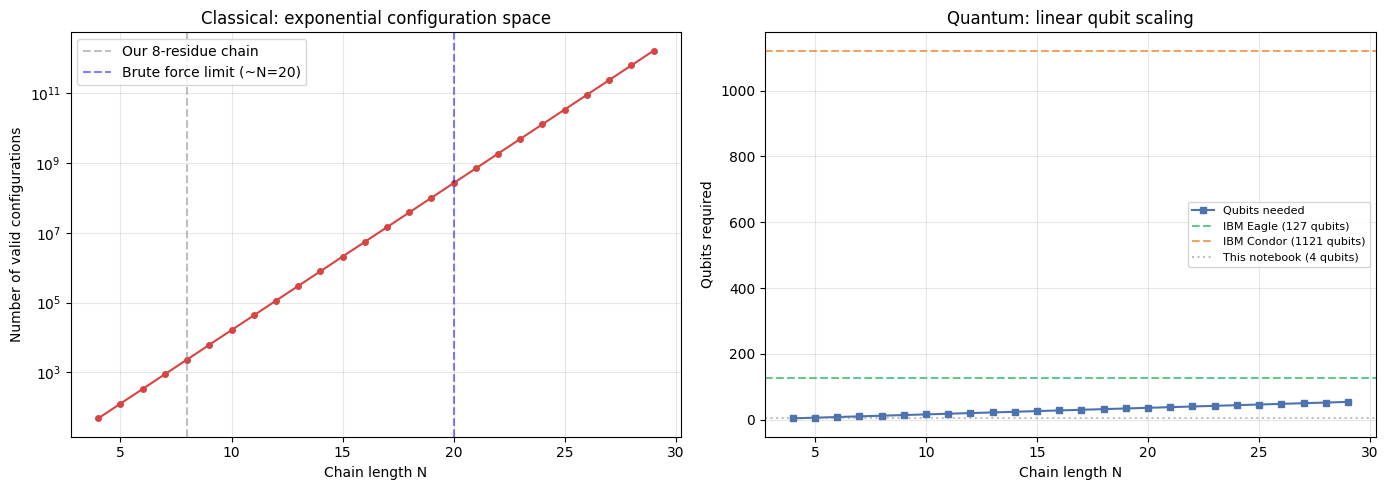

With 2(N-2) qubits per chain:
  IBM Eagle  (127 qubits):  up to N=65 residues
  IBM Condor (1121 qubits): up to N=562 residues
  Classical brute force:    up to N≈20 residues


In [23]:
chain_lengths = np.arange(4, 30)
classical_configs = 2.638 ** chain_lengths
qubits_needed = 2 * (chain_lengths - 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: classical configuration space (exponential)
axes[0].semilogy(chain_lengths, classical_configs, 'o-', color='#D64541', markersize=4)
axes[0].axvline(x=N, color='gray', linestyle='--', alpha=0.5, label=f'Our 8-residue chain')
axes[0].axvline(x=20, color='blue', linestyle='--', alpha=0.5, label='Brute force limit (~N=20)')
axes[0].set_xlabel('Chain length N')
axes[0].set_ylabel('Number of valid configurations')
axes[0].set_title('Classical: exponential configuration space')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right: quantum resource scaling (linear qubits, but note depth/noise)
ax_q = axes[1]
ax_q.plot(chain_lengths, qubits_needed, 's-', color='#4C72B0', markersize=4, label='Qubits needed')

# mark current hardware limits
ax_q.axhline(y=127, color='#27AE60', linestyle='--', alpha=0.7, label='IBM Eagle (127 qubits)')
ax_q.axhline(y=1121, color='#E67E22', linestyle='--', alpha=0.7, label='IBM Condor (1121 qubits)')
ax_q.axhline(y=4, color='gray', linestyle=':', alpha=0.5, label='This notebook (4 qubits)')

ax_q.set_xlabel('Chain length N')
ax_q.set_ylabel('Qubits required')
ax_q.set_title('Quantum: linear qubit scaling')
ax_q.legend(fontsize=8)
ax_q.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# what chain lengths fit on current hardware?
eagle_max = int((127 / 2) + 2)
condor_max = int((1121 / 2) + 2)
print(f"With 2(N-2) qubits per chain:")
print(f"  IBM Eagle  (127 qubits):  up to N={eagle_max} residues")
print(f"  IBM Condor (1121 qubits): up to N={condor_max} residues")
print(f"  Classical brute force:    up to N≈20 residues")